# 04 — Diễn giải, độ ổn định và đặt tên phân khúc

Notebook này giải thích mô hình phát triển đã khóa mà không sử dụng tập kiểm định cuối. Tên phân khúc chỉ được gán sau khi xem xét hồ sơ hành vi quan sát được và hành vi trong giai đoạn xác thực.


In [1]:
from pathlib import Path
import json, os, warnings
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "online_retail_II.csv"
OUT = ROOT / "outputs"
INTERMEDIATE = OUT / "intermediate"
REPORTS = OUT / "reports"
FIGURES = OUT / "figures"
MODELS = OUT / "models"
for directory in (INTERMEDIATE, REPORTS, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)
(ROOT / "experiments").mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEV_CUTOFF = pd.Timestamp("2010-08-31 23:59:59")
VALIDATION_END = pd.Timestamp("2010-10-31 23:59:59")
HOLDOUT_END = pd.Timestamp("2010-12-09 23:59:59")
print(f"Thư mục gốc dự án: {ROOT}")

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
import joblib

Thư mục gốc dự án: C:\Users\lqb46\Documents\Projects\Clustomer


In [2]:
seg=pd.read_csv(INTERMEDIATE/"development_segments.csv",index_col="Customer ID")
future=pd.read_csv(INTERMEDIATE/"validation_outcomes.csv",index_col="Customer ID")
selection=json.loads((REPORTS/"locked_selection.json").read_text(encoding="utf-8"))
bundle=joblib.load(MODELS/"development_model.joblib")
cols=selection["features"]
print(selection); display(seg.Cluster.value_counts().sort_index())

{'model': 'kmeans', 'feature_set': 'core_rfm', 'config': 'k=5', 'features': ['Recency', 'Frequency', 'Monetary'], 'random_state': 42, 'development_metrics': {'composite': 0.8885708900375917, 'silhouette': 0.32856830916877494, 'davies_bouldin': 0.9843047915964325, 'calinski_harabasz': 2247.774893318967, 'coverage': 1.0, 'min_segment_share': 0.0766721044045677, 'future_revenue_eta2': 0.21225595178504097, 'future_active_eta2': 0.16229793469198606, 'stability_ari': 0.9783097244384695}}


Cluster
0     760
1     235
2     568
3    1087
4     415
Name: count, dtype: int64

## 1. Hồ sơ tổng thể và hành vi trong giai đoạn xác thực

In [3]:
profile=seg.groupby("Cluster").agg(Customers=("Frequency","size"),RecencyMedian=("Recency","median"),
    FrequencyMedian=("Frequency","median"),MonetaryMedian=("Monetary","median"),AOVMedian=("AOV","median"),
    ProductDiversityMedian=("ProductDiversity","median"))
profile["CustomerShare"]=profile.Customers/len(seg)
future_profile=future.assign(Cluster=seg.Cluster).groupby("Cluster").agg(
    FutureRevenueMean=("FutureRevenue","mean"),FutureRevenueMedian=("FutureRevenue","median"),
    FutureActiveRate=("FutureActive","mean"),FutureOrdersMean=("FutureOrders","mean"))
combined=profile.join(future_profile)
display(combined)

,Customers,RecencyMedian,FrequencyMedian,MonetaryMedian,AOVMedian,ProductDiversityMedian,CustomerShare,FutureRevenueMean,FutureRevenueMedian,FutureActiveRate,FutureOrdersMean
Cluster,,,,,,,,,,,
0,760,97.000,2.000,735.920,310.655,39.000,0.248,282.008,0.000,0.480,0.672
1,235,8.000,12.000,"4,806.260",415.319,115.000,0.077,"2,144.981",897.290,0.889,3.677
2,568,34.000,5.000,"1,779.750",333.699,75.000,0.185,551.057,363.995,0.708,1.231
3,1087,153.000,1.000,208.000,178.070,14.000,0.355,94.544,0.000,0.255,0.329
4,415,16.000,2.000,468.890,262.340,29.000,0.135,217.564,0.000,0.455,0.718


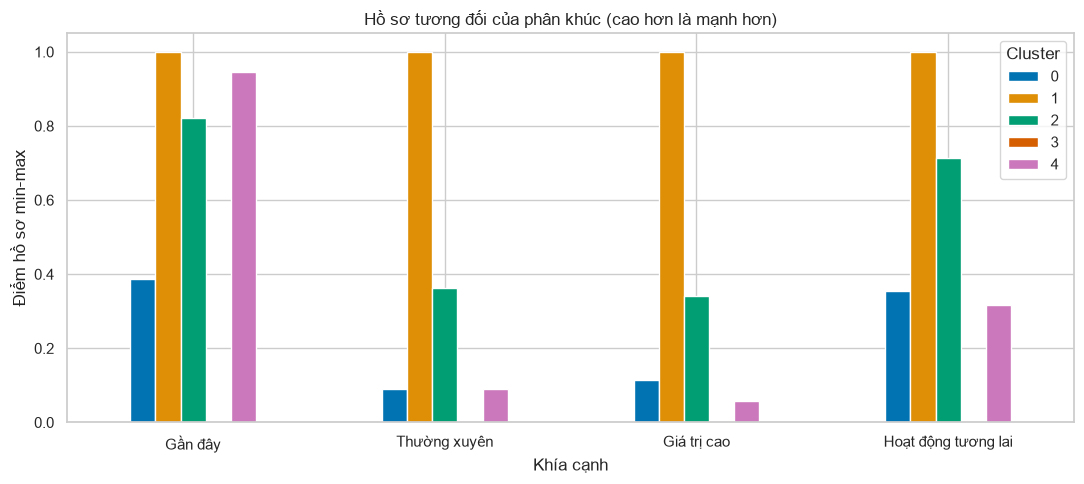

In [4]:
plot_cols=["RecencyMedian","FrequencyMedian","MonetaryMedian","FutureActiveRate"]
normalized=(combined[plot_cols]-combined[plot_cols].min())/(combined[plot_cols].max()-combined[plot_cols].min())
normalized["RecencyMedian"]=1-normalized["RecencyMedian"]
normalized.columns=["Gần đây","Thường xuyên","Giá trị cao","Hoạt động tương lai"]
ax=normalized.T.plot(kind="bar",figsize=(11,5)); ax.set(title="Hồ sơ tương đối của phân khúc (cao hơn là mạnh hơn)",ylabel="Điểm hồ sơ min-max",xlabel="Khía cạnh")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 2. Yếu tố nào chi phối việc gán phân khúc?

,feature,importance_mean,importance_sd
2,Monetary,0.422,0.003
0,Recency,0.414,0.007
1,Frequency,0.345,0.006


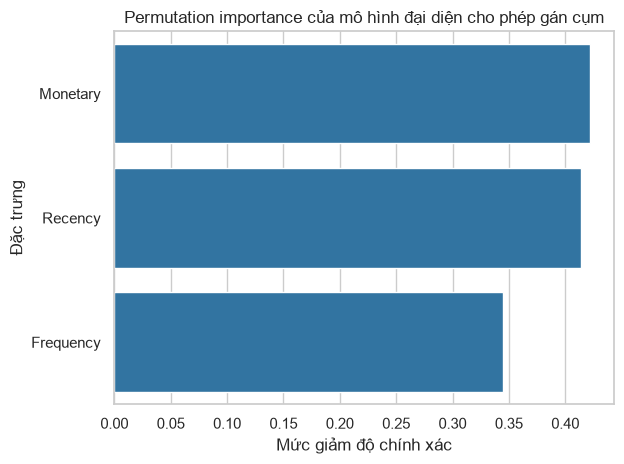

Độ chính xác huấn luyện của mô hình đại diện (chỉ để mô tả): 0.992


In [5]:
X=np.log1p(seg[cols]); y=seg.Cluster
surrogate=RandomForestClassifier(n_estimators=400,min_samples_leaf=5,random_state=RANDOM_STATE,n_jobs=1).fit(X,y)
perm=permutation_importance(surrogate,X,y,n_repeats=10,random_state=RANDOM_STATE,n_jobs=1)
importance=pd.DataFrame({"feature":cols,"importance_mean":perm.importances_mean,"importance_sd":perm.importances_std}).sort_values("importance_mean",ascending=False)
display(importance)
ax=sns.barplot(importance,x="importance_mean",y="feature",color="tab:blue"); ax.set(title="Permutation importance của mô hình đại diện cho phép gán cụm",xlabel="Mức giảm độ chính xác",ylabel="Đặc trưng")
plt.tight_layout(); plt.show()
print(f"Độ chính xác huấn luyện của mô hình đại diện (chỉ để mô tả): {surrogate.score(X,y):.3f}")

## 3. Khách hàng đại diện và khách hàng ở ranh giới

In [6]:
Z=bundle["scaler"].transform(np.log1p(seg[cols]))
if hasattr(bundle["model"],"transform"):
    distances=bundle["model"].transform(Z); assigned_distance=distances[np.arange(len(seg)),seg.Cluster.to_numpy()]
elif hasattr(bundle["model"],"predict_proba"):
    assigned_distance=1-bundle["model"].predict_proba(Z).max(axis=1)
else:
    assigned_distance=np.zeros(len(seg))
cases=seg[cols+['Cluster']].copy(); cases["AssignmentUncertainty"]=assigned_distance
representatives=cases.sort_values("AssignmentUncertainty").groupby("Cluster").head(3)
boundary=cases.sort_values("AssignmentUncertainty",ascending=False).head(12)
print("Khách hàng đại diện"); display(representatives)
print("Khách hàng ở ranh giới / cần rà soát thủ công"); display(boundary)

Khách hàng đại diện


,Recency,Frequency,Monetary,Cluster,AssignmentUncertainty
Customer ID,,,,,
16713,8,13,"5,739.600",1,0.076
18241,14,2,466.300,4,0.077
16221,15,2,445.450,4,0.088
14812,134,1,178.850,3,0.096
15042,131,1,179.520,3,0.100
16868,129,1,183.900,3,0.101
15694,33,5,"1,852.220",2,0.111
17673,29,5,"1,803.740",2,0.120
12870,13,2,492.000,4,0.122


Khách hàng ở ranh giới / cần rà soát thủ công


,Recency,Frequency,Monetary,Cluster,AssignmentUncertainty
Customer ID,,,,,
18102,1,78,"269,041.670",1,4.400
13694,20,83,"109,340.510",1,3.788
17850,44,81,"36,066.050",1,3.471
13089,1,75,"34,382.870",1,3.371
15311,5,85,"44,134.710",1,3.356
14095,258,1,2.950,3,3.176
13788,41,1,3.750,3,3.161
14866,6,1,10.000,4,3.135
17327,98,1,4.250,3,2.910


## 4. Độ ổn định qua bootstrap

In [7]:
# Khớp lại KMeans/GMM đã chọn trên các mẫu bootstrap, sau đó dự đoán toàn bộ khách hàng nếu mô hình hỗ trợ.
rng=np.random.default_rng(RANDOM_STATE); ari=[]
for _ in range(20):
    idx=rng.choice(len(Z),len(Z),replace=True)
    if selection["model"]=="kmeans":
        k=int(selection["config"].split('=')[1]); m=KMeans(n_clusters=k,n_init=20,random_state=int(rng.integers(1,10000))).fit(Z[idx]); pred=m.predict(Z)
        ari.append(adjusted_rand_score(seg.Cluster,pred))
    elif selection["model"]=="gmm":
        from sklearn.mixture import GaussianMixture
        k=int(selection["config"].split('=')[1]); m=GaussianMixture(n_components=k,reg_covar=1e-5,random_state=int(rng.integers(1,10000))).fit(Z[idx]); pred=m.predict(Z)
        ari.append(adjusted_rand_score(seg.Cluster,pred))
if ari:
    print(pd.Series(ari).describe().to_string())
else:
    print("Mô hình này không hỗ trợ dự đoán toàn quần thể cho bootstrap; sử dụng độ ổn định giữa các seed từ notebook 03.")

count   20.000
mean     0.863
std      0.076
min      0.638
25%      0.831
50%      0.854
75%      0.912
max      0.971


## 5. Tên dựa trên dữ liệu và quy ước hành động

In [8]:
# Gán tên theo vai trò hành vi quan sát được, không dựa máy móc vào mã cụm hay thứ hạng điểm.
value_score=(combined.FrequencyMedian.rank(pct=True)+combined.MonetaryMedian.rank(pct=True)+
             combined.FutureActiveRate.rank(pct=True)-combined.RecencyMedian.rank(pct=True))
remaining=set(combined.index)
champions=int(value_score.idxmax()); remaining.remove(champions)
dormant=int(combined.loc[list(remaining),"RecencyMedian"].idxmax()); remaining.remove(dormant)
new_promising=int(combined.loc[list(remaining),"RecencyMedian"].idxmin()); remaining.remove(new_promising)
loyal_growth=int(combined.loc[list(remaining),"FrequencyMedian"].idxmax()); remaining.remove(loyal_growth)
needs_attention=int(remaining.pop())
name_map={champions:"Champions",loyal_growth:"Loyal Growth",new_promising:"New & Promising",
          needs_attention:"Needs Attention",dormant:"Dormant"}
actions={"Champions":"Duy trì chất lượng dịch vụ; thử nghiệm quyền tiếp cận sớm và chương trình giới thiệu.",
         "Loyal Growth":"Phát triển giá trị giỏ hàng bằng các thử nghiệm bán chéo phù hợp.",
         "New & Promising":"Khuyến khích mua lại bằng lời nhắc đúng thời điểm với chi phí thấp.",
         "Needs Attention":"Tái kích hoạt có chọn lọc; tránh giảm giá đại trà.",
         "Dormant":"Hạn chế chiến dịch tốn kém nếu chưa chứng minh được hiệu quả gia tăng."}
named=combined.copy(); named["SegmentName"]=[name_map[int(i)] for i in named.index]; named["RecommendedAction"]=named.SegmentName.map(actions)
display(named)
(REPORTS/"segment_names.json").write_text(json.dumps(name_map,indent=2),encoding="utf-8")
named.to_csv(REPORTS/"development_segment_profiles.csv")
cases.assign(SegmentName=cases.Cluster.map(name_map)).to_csv(INTERMEDIATE/"interpreted_development_segments.csv")

,Customers,RecencyMedian,FrequencyMedian,MonetaryMedian,AOVMedian,ProductDiversityMedian,CustomerShare,FutureRevenueMean,FutureRevenueMedian,FutureActiveRate,FutureOrdersMean,SegmentName,RecommendedAction
Cluster,,,,,,,,,,,,,
0,760,97.000,2.000,735.920,310.655,39.000,0.248,282.008,0.000,0.480,0.672,Needs Attention,Tái kích hoạt có chọn lọc; tránh giảm giá đại ...
1,235,8.000,12.000,"4,806.260",415.319,115.000,0.077,"2,144.981",897.290,0.889,3.677,Champions,Duy trì chất lượng dịch vụ; thử nghiệm quyền t...
2,568,34.000,5.000,"1,779.750",333.699,75.000,0.185,551.057,363.995,0.708,1.231,Loyal Growth,Phát triển giá trị giỏ hàng bằng các thử nghiệ...
3,1087,153.000,1.000,208.000,178.070,14.000,0.355,94.544,0.000,0.255,0.329,Dormant,Hạn chế chiến dịch tốn kém nếu chưa chứng minh...
4,415,16.000,2.000,468.890,262.340,29.000,0.135,217.564,0.000,0.455,0.718,New & Promising,Khuyến khích mua lại bằng lời nhắc đúng thời đ...


## Quyết định diễn giải

Tên phân khúc mô tả hành vi tương đối, không đại diện cho giá trị con người của khách hàng hay phản ứng nhân quả với chiến dịch. Độ bất định cao khi gán phân khúc là tín hiệu cần rà soát thủ công. Các khuyến nghị chiến dịch chỉ là giả thuyết cần được kiểm chứng bằng thử nghiệm lift có đối chứng; dữ liệu phân cụm không thể tự chứng minh rằng giảm giá hay liên hệ khách hàng sẽ tạo ra doanh thu.
